# Linear Regression Algorithm

In [11]:
class MyLinearModel():
    def __init__(self):
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        num = 0
        den = 0
        for i in range(X_train.shape[0]):
            num = num + ((X_train[i] - X_train.mean()) * (y_train[i] - y_train.mean()))
            den = den + (X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean())

        self.m = num / den
        self.b = y_train.mean() - (self.m * X_train.mean())

        print(self.m)
        print(self.b)
            
            
    def predict(self,X_test):
        return self.m * X_test + self.b

In [12]:
import numpy as np
import pandas as pd

df = pd.read_csv("placement.csv")
print(df.head())

   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57


# Feature & Label Selection

In [13]:
X = df.iloc[:,0].values
y = df.iloc[:,1].values

# Data Splitting

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y)

# Model Training

In [17]:
model = MyLinearModel()
model.fit(X_train,y_train)

0.5961988323826881
-1.1478853157844418


# Prediction

In [18]:
prediction = model.predict(X_test)
print(prediction)

[4.24175213 3.96750067 4.18213225 3.11493634 2.98377259 2.9778106
 3.68728721 2.95992464 3.31168195 3.28187201 2.88241879 2.78702698
 1.67213516 3.24013809 2.37564978 3.04935446 3.09108838 2.33391587
 3.20436616 2.54258546 3.88403283 3.00165856 2.56047142 2.93607669
 3.55612347 4.37291587 3.26398604 3.74094511 3.22821411 2.4173837
 2.86453283 2.78106499 3.71113517 2.35776382 3.15070827 2.70952113
 3.2341761  3.13878429 3.5918954  2.94800066 3.88403283 3.41899774
 2.60220534 3.25206207 2.98377259 3.68132523 3.51438955 3.30571996
 3.67536324 2.33391587]


# Evaluation

In [19]:
from sklearn.metrics import mean_squared_error,r2_score

mse = mean_squared_error(y_test,prediction)
R2 = r2_score(y_test,prediction)

print("Mean Squared Error: ", mse)
print("R2: ", R2)

Mean Squared Error:  0.17028274620707076
R2:  0.49959350354519183


# Visualize Best Fit Line

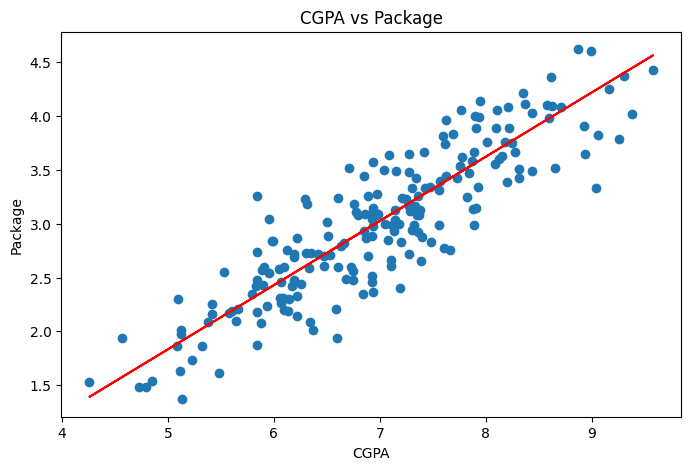

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(X,y)
plt.plot(X_train,model.predict(X_train),color="red")
plt.title("CGPA vs Package")
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.show()